Procrustes Distance = 0.11215348605967775


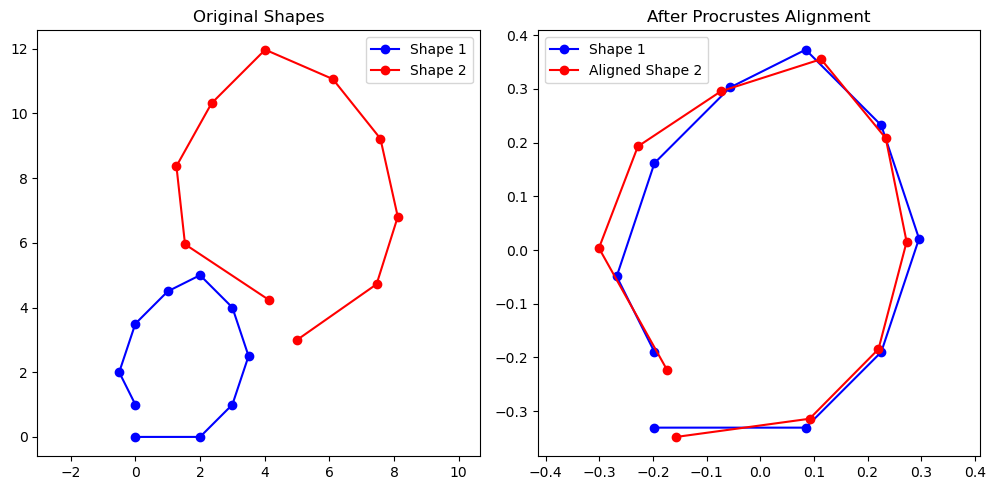

In [15]:
import numpy as np
import matplotlib.pyplot as plt

shape1 = np.array([
    [0.0, 0.0],
    [2.0, 0.0],
    [3.0, 1.0],
    [3.5, 2.5],
    [3.0, 4.0],
    [2.0, 5.0],
    [1.0, 4.5],
    [0.0, 3.5],
    [-0.5, 2.0],
    [0.0, 1.0]
], dtype=float)

shape2 = np.array([
    [5.0000, 3.0000],
    [7.4575, 4.7207],
    [8.1135, 6.8066],
    [7.5766, 9.2214],
    [6.1046,11.0642],
    [4.0144,11.9719],
    [2.3556,10.3143],
    [1.2698, 8.3706],
    [1.5354, 5.9558],
    [4.1394, 4.2287]
], dtype=float)


#Remove Translation
centroid1 = np.mean(shape1, axis=0)
centroid2 = np.mean(shape2, axis=0)

shape1_centered = shape1 - centroid1
shape2_centered = shape2 - centroid2


#Remove Scale
norm1 = np.linalg.norm(shape1_centered)
norm2 = np.linalg.norm(shape2_centered)

shape1_normalized = shape1_centered / norm1
shape2_normalized = shape2_centered / norm2

#Find Best Rotation

H = shape2_normalized.T @ shape1_normalized
U, S, Vt = np.linalg.svd(H)  # Vt = V transpose
R = Vt.T @ U.T     # R= V*Utranspose 

# Remove reflection 
if np.linalg.det(R) < 0:
    Vt[-1, :] *= -1
    R = Vt.T @ U.T

shape2_aligned = shape2_normalized @ R.T  # Rotate shape2


#Compute Procrustes Distance

distance = np.sqrt(np.sum((shape1_normalized - shape2_aligned) ** 2))

print("Procrustes Distance =", distance)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.plot(shape1[:,0], shape1[:,1], 'bo-', label='Shape 1')
plt.plot(shape2[:,0], shape2[:,1], 'ro-', label='Shape 2')

plt.title("Original Shapes")
plt.axis("equal")
plt.legend()

plt.subplot(1,2,2)

plt.plot(shape1_normalized[:,0], shape1_normalized[:,1],
         'bo-', label='Shape 1')

plt.plot(shape2_aligned[:,0], shape2_aligned[:,1],
         'ro-', label='Aligned Shape 2')

plt.title("After Procrustes Alignment")
plt.axis("equal")
plt.legend()

plt.tight_layout()
plt.show()